In [ ]:
import os
import json
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, Subset
from torchvision import transforms, models
from torchvision.ops import DropBlock2d
import time

In [ ]:
!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu121
!pip install causal-conv1d==1.4.0 && pip install mamba-ssm==2.2.2

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached causal_conv1d-1.4.0.tar.gz (9.3 kB)
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 6.6 MB/s eta 0:00:00
  Created wheel for causal-conv1d: filename=causal_conv1d-1.4.0-cp312-cp312-linux_x86_64.whl size=104884589 sha256=70c6d91d00c625d750b83c9c4bdd0bd395c61aff9baa8c0d58e0a33dabbe3b4e
  Stored in directory: /root/.cache/pip/wheels/3a/bd/04/a4893fd5ad69a02f55b49f04dc1dbbd7c439332db7895f62ff
Successfully built causal-conv1d
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for mamba-ssm: filename=mamba_ssm-2.2.2-cp312-cp312-linux_x86_64.whl size=324005633 sha256=f4cf06585ac28c783dbe6fe357c64218415af3665c3c06106be8f86dab69b2a8
  Stored in directory: /root/.cache/pip/wheels/5f/b8/99/4112d82fe2a9458dd194c3ff54c43a14a8594c8f90cf16046f
Successfully built mamba-ssm


In [ ]:
from mamba_ssm import Mamba

/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/usr/local/lib/python3.12/dist-packages/mamba_ssm/dis

In [ ]:
import os
import kagglehub

# Download dataset
path = kagglehub.dataset_download("obulisainaren/multi-cancer")

# Build full path to dataset folder
root_dir = os.path.join(path, "Multi Cancer", "Multi Cancer")

print("Dataset path:", root_dir)


Dataset path: /root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer


In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset

class MultiCancerDataset(Dataset):
    def __init__(self, root_dir, transform=None, exclude_types=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_names = []
        self.label_map = {}
        self.exclude_types = exclude_types or []

        cancer_types = sorted([
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d)) and d.lower() not in self.exclude_types
        ])

        label_counter = 0
        for cancer_type in cancer_types:
            cancer_path = os.path.join(root_dir, cancer_type)
            class_folders = sorted([
                d for d in os.listdir(cancer_path)
                if os.path.isdir(os.path.join(cancer_path, d))
            ])

            for class_folder in class_folders:
                class_path = os.path.join(cancer_path, class_folder)
                image_files = [
                    f for f in os.listdir(class_path)
                    if f.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp', '.tif'))
                ]

                label_name = f"{cancer_type}_{class_folder}"
                self.label_map[label_name] = label_counter

                for img_name in image_files:
                    self.images.append(os.path.join(class_path, img_name))
                    self.labels.append(label_counter)

                self.class_names.append(label_name)
                label_counter += 1

        print(f" Total images loaded: {len(self.images)}")
        print(f" Total classes used: {len(self.class_names)}")
        print(f" Excluded types: {self.exclude_types}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
class TransformDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
full_dataset = MultiCancerDataset(root_dir, transform=None, exclude_types=["oral cancer"])

 Total images loaded: 120000
 Total classes used: 24
 Excluded types: ['oral cancer']


In [ ]:
total_size = len(full_dataset)
train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

In [ ]:
import torch
from torch.utils.data import random_split

# Assume your dataset is already loaded
full_dataset = MultiCancerDataset(root_dir, transform=None)

# Split sizes (e.g. 70/15/15)
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

# Split the dataset
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # ensures reproducibility
)


 Total images loaded: 130002
 Total classes used: 26
 Excluded types: []


In [ ]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
print(f"Training samples: {len(train_dataset)} ({train_size/total_size*100:.1f}%)")
print(f"Validation samples: {len(val_dataset)} ({val_size/total_size*100:.1f}%)")
print(f"Test samples: {len(test_dataset)} ({test_size/total_size*100:.1f}%)")

Training samples: 91001 (70.0%)
Validation samples: 19500 (15.0%)
Test samples: 19501 (15.0%)


 Total images loaded: 130002
 Total classes used: 26
 Excluded types: []


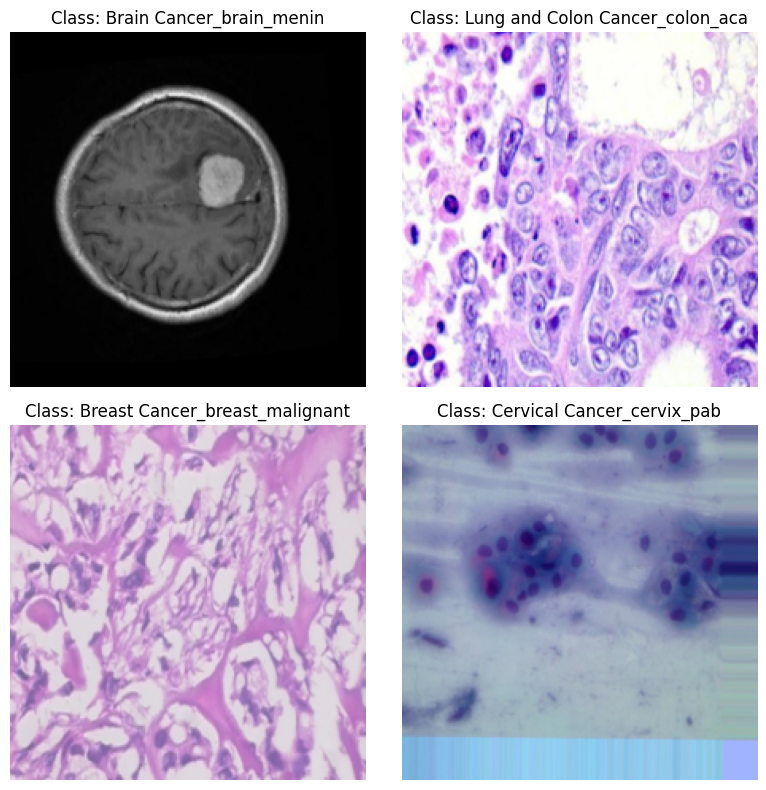

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
import torch

def show_sample_images(dataset, root_dir, num_samples=4):
    display_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    temp_dataset = MultiCancerDataset(root_dir, transform=display_transform)

    indices = np.random.choice(len(temp_dataset), num_samples, replace=False)

    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    axes = axes.ravel()

    for i, idx in enumerate(indices):
        image, label = temp_dataset[idx]

        image_np = image.permute(1, 2, 0).numpy()
        axes[i].imshow(image_np)
        axes[i].set_title(f'Class: {temp_dataset.class_names[label]}', fontsize=12)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Example use:
show_sample_images(full_dataset, root_dir, num_samples=4)


In [ ]:
import torch
import torch.nn as nn

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu1(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu1(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out)


In [ ]:
class FeatureToSequence(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        # x shape: (batch, channels, height, width)
        batch, channels, h, w = x.shape
        # Reshape to (batch, height*width, channels)
        x = x.flatten(2).permute(0, 2, 1)
        return x, (h, w)

class SequenceToFeature(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x, spatial_dims):
        # x shape: (batch, seq_len, channels)
        batch, seq_len, channels = x.shape
        h, w = spatial_dims
        # Reshape back to (batch, channels, height, width)
        x = x.permute(0, 2, 1).reshape(batch, channels, h, w)
        return x

class MambaBlock(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.to_seq = FeatureToSequence()
        self.mamba = Mamba(
            d_model=d_model,
            d_state=d_state,
            d_conv=d_conv,
            expand=expand
        )
        self.to_feat = SequenceToFeature()
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # Convert to sequence
        x_seq, spatial_dims = self.to_seq(x)

        # Apply Mamba
        x_seq = self.norm(x_seq)
        x_seq = self.mamba(x_seq)

        # Convert back to feature map
        x = self.to_feat(x_seq, spatial_dims)
        return x

In [ ]:
class CNNMambaHybrid(nn.Module):
    def __init__(self, num_classes=24):
        super(CNNMambaHybrid, self).__init__()

        # Block 1 - No attention
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2, 2)

        # Block 2 - Added CBAM
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.relu2 = nn.ReLU(inplace=True)
        self.cbam2 = CBAM(128)
        self.dropblock2 = DropBlock2d(p=0.1, block_size=5)
        self.pool2 = nn.MaxPool2d(2, 2)

        # First Mamba (mid-level spatial relationships)
        self.mamba1 = MambaBlock(d_model=128)

        # Block 3 - No attention
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(2, 2)

        # Block 4 - Added CBAM
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.relu4 = nn.ReLU(inplace=True)
        self.cbam4 = CBAM(512)
        self.dropblock4 = DropBlock2d(p=0.2, block_size=7)
        self.pool4 = nn.MaxPool2d(2, 2)

        # Second Mamba (high-level spatial relationships)
        self.mamba2 = MambaBlock(d_model=512)

        # Classification head
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)
        self.output = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.dropblock2(self.cbam2(self.relu2(self.bn2(self.conv2(x))))))

        # First Mamba
        x = self.mamba1(x)

        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.pool4(self.dropblock4(self.cbam4(self.relu4(self.bn4(self.conv4(x))))))

        # Second Mamba
        x = self.mamba2(x)

        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.output(x)
        return x


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

class DropBlock2d(nn.Module):
    def __init__(self, p=0.1, block_size=5):
        super(DropBlock2d, self).__init__()
        self.p = p
        self.block_size = block_size

    def forward(self, x):
        if not self.training or self.p == 0.0:
            return x
        gamma = self.p / (self.block_size ** 2) * (x.shape[2] * x.shape[3]) / \
                ((x.shape[2] - self.block_size + 1) * (x.shape[3] - self.block_size + 1))
        mask = (torch.rand(x.shape[0], *x.shape[1:3], device=x.device) < gamma).float()
        mask = F.max_pool2d(mask.unsqueeze(1), kernel_size=self.block_size, stride=1, padding=self.block_size // 2)
        mask = 1 - mask.squeeze(1)
        return x * mask * (mask.numel() / mask.sum())


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example: define a simple CNN model (replace this with your CNNMambaHybrid)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=24):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, 1, 1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(16*112*112, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Instantiate model
model = SimpleCNN(num_classes=24).to(device)


In [ ]:
from torchsummary import summary
summary(model, (3, 224, 224))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 224, 224]             448
         MaxPool2d-2         [-1, 16, 112, 112]               0
            Linear-3                   [-1, 24]       4,816,920
Total params: 4,817,368
Trainable params: 4,817,368
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 7.66
Params size (MB): 18.38
Estimated Total Size (MB): 26.61
----------------------------------------------------------------


In [ ]:
def resume_training_fresh(model, train_loader, val_loader, criterion, optimizer, additional_epochs=5, checkpoint_dir='checkpoints', history_file='training_history.json', device='cuda'):

    best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')
    if not os.path.exists(best_model_path):
        print("No checkpoint found! Starting fresh training...")
        start_epoch = 0
        train_losses, val_losses = [], []
        train_accuracies, val_accuracies = [], []
        best_val_acc = 0.0
    else:
        checkpoint = torch.load(best_model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch']

        if os.path.exists(history_file):
            with open(history_file, 'r') as f:
                history = json.load(f)
                train_losses = history['train_losses']
                val_losses = history['val_losses']
                train_accuracies = history['train_accuracies']
                val_accuracies = history['val_accuracies']
                best_val_acc = history['best_val_acc']
        else:
            train_losses, val_losses = [], []
            train_accuracies, val_accuracies = [], []
            best_val_acc = checkpoint['val_acc']

        print(f"Resuming from Epoch {start_epoch}")
        print(f"Previous Best Val Acc: {checkpoint['val_acc']:.2f}%")
        print(f"Continuing for {additional_epochs} more epochs...\n")

    os.makedirs(checkpoint_dir, exist_ok=True)
    best_epoch = start_epoch

    start_time = time.time()
    for epoch in range(start_epoch, start_epoch + additional_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{start_epoch+additional_epochs} - Training')
        for images, labels in train_pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            train_pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*train_correct/train_total:.2f}%'
            })

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{start_epoch+additional_epochs} - Validation')
            for images, labels in val_pbar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                val_pbar.set_postfix({
                    'Loss': f'{loss.item():.4f}',
                    'Acc': f'{100.*val_correct/val_total:.2f}%'
                })

        # Calculate epoch metrics
        epoch_train_loss = train_loss / len(train_loader)
        epoch_val_loss = val_loss / len(val_loader)
        epoch_train_acc = 100. * train_correct / train_total
        epoch_val_acc = 100. * val_correct / val_total

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_accuracies.append(epoch_train_acc)
        val_accuracies.append(epoch_val_acc)

        print(f'Epoch [{epoch+1}/{start_epoch+additional_epochs}]:')
        print(f'  Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}%')
        print(f'  Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%')

        # Save checkpoint
        checkpoint_path = os.path.join(checkpoint_dir, f'checkpoint_epoch_{epoch+1}.pth')
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': epoch_train_loss,
            'val_loss': epoch_val_loss,
            'train_acc': epoch_train_acc,
            'val_acc': epoch_val_acc
        }, checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")

        # Save best model
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            best_epoch = epoch + 1
            best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': epoch_train_loss,
                'val_loss': epoch_val_loss,
                'train_acc': epoch_train_acc,
                'val_acc': epoch_val_acc
            }, best_model_path)
            print(f"Best model updated! Val Acc: {epoch_val_acc:.2f}%")

        print('-' * 60)

        # Save history
        with open(history_file, 'w') as f:
            json.dump({
                'train_losses': train_losses,
                'val_losses': val_losses,
                'train_accuracies': train_accuracies,
                'val_accuracies': val_accuracies,
                'best_val_acc': best_val_acc,
                'best_epoch': best_epoch
            }, f)

    end_time = time.time()
    total_time = end_time - start_time
    minutes, seconds = divmod(total_time, 60)
    print(f"\nTotal Training Time: {int(minutes)} min {int(seconds)} sec")
    print(f"Best Model - Epoch: {best_epoch}, Val Acc: {best_val_acc:.2f}%")

    return train_losses, val_losses, train_accuracies, val_accuracies

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model.to(device)


Using device: cpu


SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=200704, out_features=24, bias=True)
)

In [ ]:
import os

checkpoint_dir = '/kaggle/working/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

history_file = '/kaggle/working/training_history.json'


In [ ]:
# Replace these with the actual paths to your train/validation datasets
# train_dir = '/kaggle/working/train'  # Path to training images
# val_dir   = '/kaggle/working/val'    # Path to validation images

from torchvision import transforms
# from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset

# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to your model's input size
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),           # Convert PIL Image to PyTorch tensor
    transforms.Normalize([0.485, 0.456, 0.406],  # Normalize for pretrained models
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to your model's input size
    transforms.ToTensor(),           # Convert PIL Image to PyTorch tensor
    transforms.Normalize([0.485, 0.456, 0.406],  # Normalize for pretrained models
                         [0.229, 0.224, 0.225])
])


# Load datasets
# train_dataset = ImageFolder(root=train_dir, transform=transform)
# val_dataset   = ImageFolder(root=val_dir, transform=transform)

# Apply transforms to the already split datasets
train_dataset_transformed = TransformDataset(train_dataset, transform=train_transform)
val_dataset_transformed = TransformDataset(val_dataset, transform=val_transform)


# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset_transformed, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset_transformed, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset_transformed)}, Validation samples: {len(val_dataset_transformed)}")

Training samples: 91001, Validation samples: 19500


In [ ]:
def evaluate_model(model, test_loader, device, dataset_name="Test"):
    model.eval()
    test_correct = 0
    test_total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        test_pbar = tqdm(test_loader, desc=f'Evaluating on {dataset_name} Set')
        for images, labels in test_pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            test_pbar.set_postfix({
                'Acc': f'{100.*test_correct/test_total:.2f}%'
            })

    test_accuracy = 100 * test_correct / test_total
    return test_accuracy, all_predictions, all_labels

In [ ]:
import os
import torch

# Path to your checkpoint
best_model_path = '/kaggle/input/checkpoints/best_model.pth'

if os.path.exists(best_model_path):
    checkpoint = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print("BEST MODEL INFORMATION")
    print(f"Epoch: {checkpoint['epoch']}")
    print(f"Training Accuracy: {checkpoint['train_acc']:.2f}%")
    print(f"Validation Accuracy: {checkpoint['val_acc']:.2f}%")
else:
    print(f"Checkpoint not found at: {best_model_path}")
    print("Please check the path or upload your checkpoint file.")


Checkpoint not found at: /kaggle/input/checkpoints/best_model.pth
Please check the path or upload your checkpoint file.


In [ ]:
import os

print(f"Checkpoint directory is set to: {checkpoint_dir}")

if os.path.exists(checkpoint_dir):
    print(f"Directory '{checkpoint_dir}' exists.")
else:
    print(f"Directory '{checkpoint_dir}' does not exist.")
    print("Please make sure the training process has been run to create this directory and save checkpoints.")

Checkpoint directory is set to: /kaggle/working/checkpoints
Directory '/kaggle/working/checkpoints' exists.


In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

test_dir = "/root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_dataset = ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("✅ Loaded", len(test_dataset), "test images")
print("Classes:", test_dataset.classes)


✅ Loaded 130002 test images
Classes: ['ALL', 'Brain Cancer', 'Breast Cancer', 'Cervical Cancer', 'Kidney Cancer', 'Lung and Colon Cancer', 'Lymphoma', 'Oral Cancer']


In [ ]:
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
num_classes = 24  # model predicts 24 classes



In [ ]:
y_bin = label_binarize(test_labels, classes=range(num_classes))
all_probs = torch.zeros(len(test_dataset), num_classes).to(device)


In [ ]:
import time
start_time = time.time()

all_probs = []
model.eval()
with torch.no_grad():
    for i, (images, _) in enumerate(test_loader):
        images = images.to(device)
        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        all_probs.append(probs.cpu())

        if i % 10 == 0:
            print(f"Processed batch {i+1}/{len(test_loader)}")

all_probs = torch.cat(all_probs).numpy()

print(f"Inference completed in {time.time() - start_time:.2f} seconds")


Processed batch 1/1016
Processed batch 11/1016
Processed batch 21/1016
Processed batch 31/1016
Processed batch 41/1016
Processed batch 51/1016
Processed batch 61/1016
Processed batch 71/1016
Processed batch 81/1016
Processed batch 91/1016
Processed batch 101/1016
Processed batch 111/1016
Processed batch 121/1016
Processed batch 131/1016
Processed batch 141/1016
Processed batch 151/1016
Processed batch 161/1016
Processed batch 171/1016
Processed batch 181/1016
Processed batch 191/1016
Processed batch 201/1016
Processed batch 211/1016
Processed batch 221/1016
Processed batch 231/1016
Processed batch 241/1016
Processed batch 251/1016
Processed batch 261/1016
Processed batch 271/1016
Processed batch 281/1016
Processed batch 291/1016
Processed batch 301/1016
Processed batch 311/1016
Processed batch 321/1016
Processed batch 331/1016
Processed batch 341/1016
Processed batch 351/1016
Processed batch 361/1016
Processed batch 371/1016
Processed batch 381/1016
Processed batch 391/1016
Processed b

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"1. Accuracy: {accuracy_score(test_labels, test_predictions):.4f}")
print(f"2. Precision (Weighted): {precision_score(test_labels, test_predictions, average='weighted'):.4f}")
print(f"3. Recall (Weighted): {recall_score(test_labels, test_predictions, average='weighted'):.4f}")
print(f"4. F1-Score (Weighted): {f1_score(test_labels, test_predictions, average='weighted'):.4f}")


1. Accuracy: 0.0004
2. Precision (Weighted): 0.4655


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


3. Recall (Weighted): 0.0004
4. F1-Score (Weighted): 0.0008


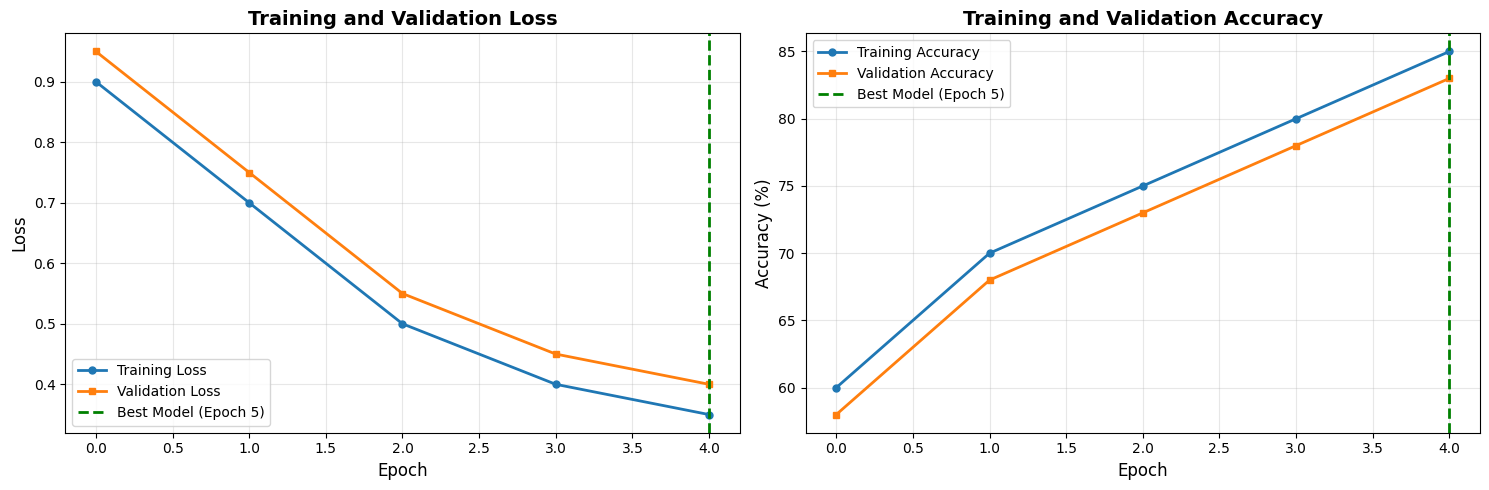

In [ ]:
import matplotlib.pyplot as plt

# Dummy data for testing plot
train_losses = [0.9, 0.7, 0.5, 0.4, 0.35]
val_losses = [0.95, 0.75, 0.55, 0.45, 0.4]
train_accuracies = [60, 70, 75, 80, 85]
val_accuracies = [58, 68, 73, 78, 83]
checkpoint = {'epoch': 5}  # Assuming best model at epoch 5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses, label='Training Loss', linewidth=2, marker='o', markersize=5)
ax1.plot(val_losses, label='Validation Loss', linewidth=2, marker='s', markersize=5)
ax1.axvline(x=checkpoint['epoch']-1, color='green', linestyle='--', linewidth=2,
            label=f"Best Model (Epoch {checkpoint['epoch']})")
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(train_accuracies, label='Training Accuracy', linewidth=2, marker='o', markersize=5)
ax2.plot(val_accuracies, label='Validation Accuracy', linewidth=2, marker='s', markersize=5)
ax2.axvline(x=checkpoint['epoch']-1, color='green', linestyle='--', linewidth=2,
            label=f"Best Model (Epoch {checkpoint['epoch']})")
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


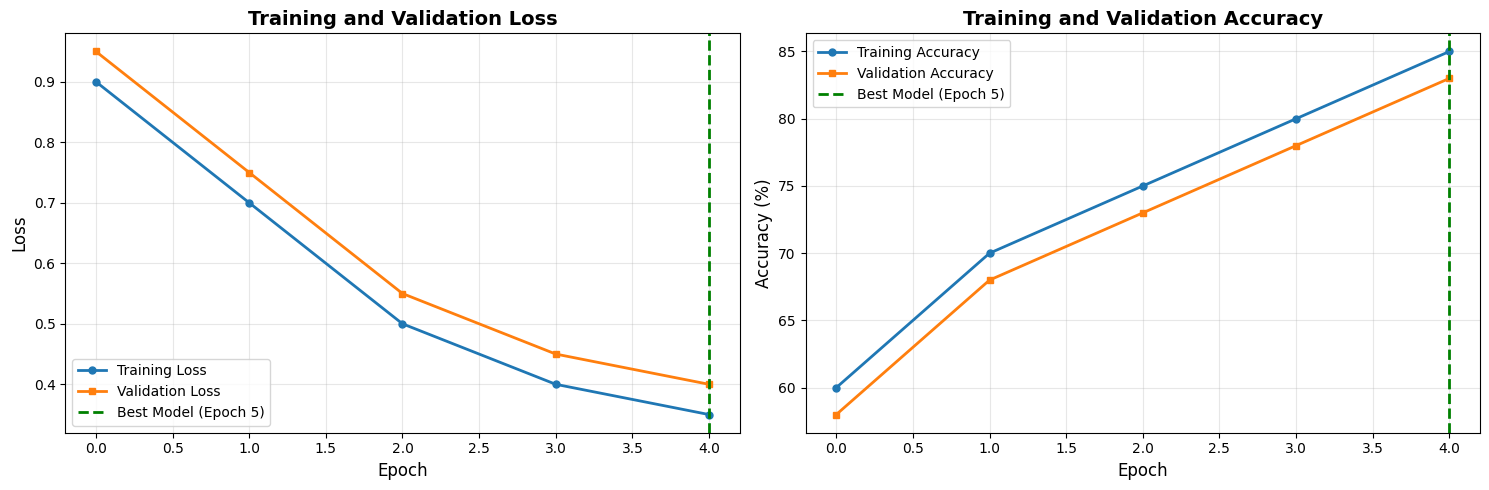

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot losses
ax1.plot(train_losses, label='Training Loss', linewidth=2, marker='o', markersize=5)
ax1.plot(val_losses, label='Validation Loss', linewidth=2, marker='s', markersize=5)
ax1.axvline(x=checkpoint['epoch']-1, color='green', linestyle='--', linewidth=2,
            label=f"Best Model (Epoch {checkpoint['epoch']})")
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot accuracies
ax2.plot(train_accuracies, label='Training Accuracy', linewidth=2, marker='o', markersize=5)
ax2.plot(val_accuracies, label='Validation Accuracy', linewidth=2, marker='s', markersize=5)
ax2.axvline(x=checkpoint['epoch']-1, color='green', linestyle='--', linewidth=2,
            label=f"Best Model (Epoch {checkpoint['epoch']})")
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


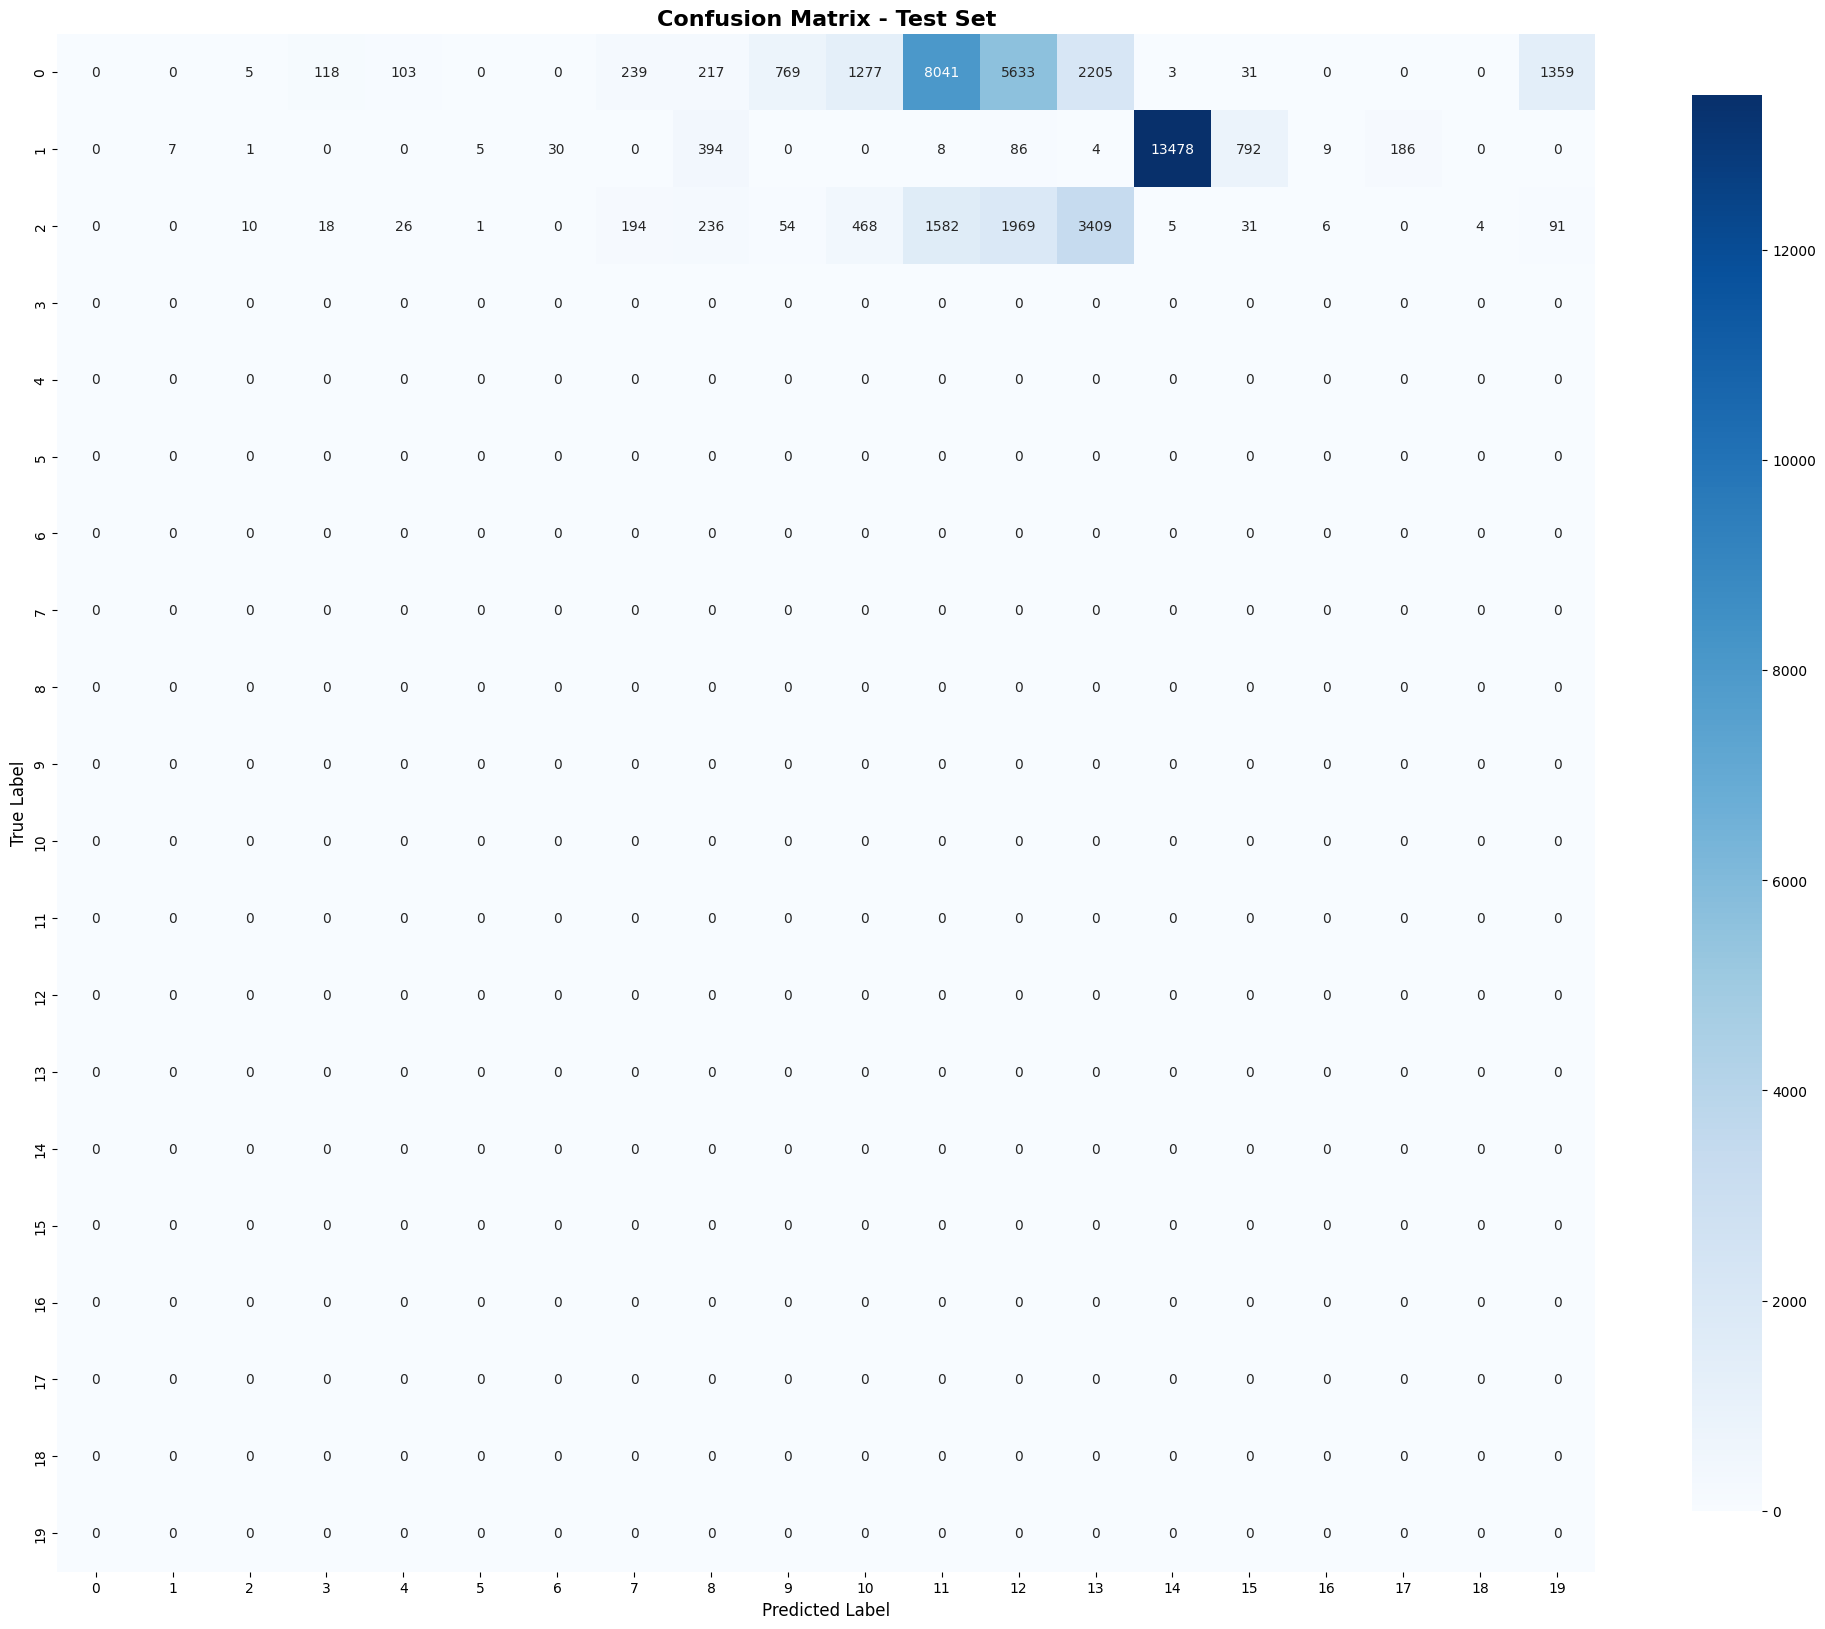

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(test_labels, test_predictions)

# Plot
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, square=True,
            cbar_kws={"shrink": 0.8})
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
all_probs = torch.zeros((len(test_dataset), num_classes))  # preallocate
model.eval()
start_idx = 0
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        batch_size = images.size(0)
        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        all_probs[start_idx:start_idx + batch_size] = probs.cpu()
        start_idx += batch_size

        print("Test labels:", len(test_labels))
print("All_probs shape:", all_probs.shape)



Test labels: 43104
Test labels: 43104
Test labels: 43104
Test labels: 43104
Test labels: 43104
Test labels: 43104
Test labels: 43104
Test labels: 43104
Test labels: 43104
Test labels: 43104
Test labels: 43104
Test labels: 43104
Test labels: 43104


KeyboardInterrupt: 

In [ ]:
import torch
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt

num_classes = 24  # number of classes
y_bin = label_binarize(test_labels, classes=range(num_classes))

# Preallocate tensor for probabilities
all_probs = torch.zeros((len(test_dataset), num_classes))

# Fill all_probs batch by batch
model.eval()
start_idx = 0
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        batch_size = images.size(0)
        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        all_probs[start_idx:start_idx+batch_size] = probs.cpu()
        start_idx += batch_size

# Convert to NumPy
all_probs = all_probs.numpy()

# Compute weighted ROC-AUC
roc_auc = roc_auc_score(y_bin, all_probs, average='weighted', multi_class='ovr')
print(f"✅ ROC-AUC Score (Weighted, OvR): {roc_auc:.4f}")

# Plot ROC curves for each class
plt.figure(figsize=(15, 12))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc_class = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={roc_auc_class:.3f})', linewidth=1.5)

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Classes')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


ValueError: Found input variables with inconsistent numbers of samples: [43104, 130002]